# Лабораторная работа 2 — прогноз счастья

В строках `Неизвестно` отсутствуют все признаки состояния, поэтому прямое использование состояний в классификаторе даёт завышенную проверку на known и бесполезный прогноз для unknown. Рабочая схема:

1. удаляем мультиколлинеарные признаки-причины итеративным VIF-фильтром: пока максимальный `VIF >= 8`, убираем признак с максимальным VIF;
2. сортируем признаки состояния по связи со счастьем через `abs(Spearman)` и оставляем кандидатов с `abs(Spearman) >= 0.50`;
3. для каждого кандидата строим линейный МНК по оставшимся причинам и сфере занятости;
4. если линейный `R2_train < 0.80`, прогоняем причины через банк линеаризующих функций: `z`, `z^2`, `z^3`, `z^4`, `log1p`, `sqrt`, `1/(1+x)`;
5. после банка функций снова проверяем `R2_train` и берём только состояния с итоговым `R2_train >= 0.80`;
6. восстанавливаем выбранные состояния через `Ridge` по линеаризованным причинам, затем предсказываем класс счастья логистической регрессией.

`community_id` создаётся для диагностики и графиков, но не подаётся в основную модель, чтобы не запоминать сообщества напрямую.


In [2]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import precision_score, accuracy_score, classification_report, confusion_matrix, r2_score, ConfusionMatrixDisplay

try:
    from IPython.display import display
except Exception:
    display = print

In [ ]:
DATA_PATH = Path("Вар_42_Б24-215_Гаганидзе_Лаба2_студент" + ".xlsx")
TARGET, UNKNOWN, CAT_COL = "Ощущаемое счастье", "Неизвестно", "Сфера занятости"
SEED = 27
N_TOP_STATES = 6

RHO_MIN, RHO_MAX = 0.40, 0.75
SPEARMAN_MIN = 0.50
R2_MIN = 0.80
VIF_MAX = 8.0
REG_ALPHA = 1.0
LOGREG_C = 8.0

CLASS_ORDER = ["Hopeless", "Depressed", "Suffering", "Strugglng", "Coping", "Just ok", "Doing well", "Blooming", "Thriving", "Prospering"]
class_to_rank = {c: i for i, c in enumerate(CLASS_ORDER)}
rank_to_class = {i: c for i, c in enumerate(CLASS_ORDER)}

CAUSE_COLS = [
    "Среднегодовой доход, тыс. $", "Объем потребленного алкоголя в год, л.", "Количество членов семьи",
    "Количество лет образования", "Доля от дохода семьи которая тратится на продовольствие, %",
    "Коэффициент Джини сообщества", "Издержки сообщества на окружающую среду, млн. $",
    "Охват беспроводной связи в сообществе, %",
    "Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек",
    "Волатильность потребительских цен в сообществе",
]
COMMUNITY_CAUSE_COLS = CAUSE_COLS[5:]
STATE_COLS = [
    "Оценка благополучия", "Оценка социальной поддержки", "Ожидаемая продолжительность здоровой жизни",
    "Свобода граждан самостоятельно принимать жизненно важные решения", "Индекс Щедрости",
    "Индекс отношения к коррупции", "Оценка риска безработицы", "Индекс кредитного оптимизма",
    "Индекс страха социальных конфликтов", "Индекс семьи", "Индекс продовольственной безопасности",
    "Чувство технологического прогресса", "Чувство неравенства доходов в обществе",
]


In [ ]:
def add_community_id(data):
    data = data.copy()
    data["community_id"] = data[COMMUNITY_CAUSE_COLS].round(8).astype(str).agg("|".join, axis=1)
    return data

def make_cause_X(part, cause_cols=None, use_sphere=True, use_community=False, columns=None):
    cause_cols = CAUSE_COLS if cause_cols is None else list(cause_cols)
    X = part[cause_cols].astype(float).copy()
    if use_sphere:
        X = X.join(pd.get_dummies(part[CAT_COL], prefix="sphere", dtype=float))
    if use_community:
        X = X.join(pd.get_dummies(part["community_id"], prefix="community", dtype=float))
    X.columns = X.columns.astype(str)
    return X if columns is None else X.reindex(columns=columns, fill_value=0)

def compute_vif_table(data, cause_cols):
    X = data[list(cause_cols)].astype(float).copy()
    X_scaled = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(X))
    return pd.DataFrame({
        "feature": list(cause_cols),
        "VIF": [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])],
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

def select_low_vif_causes(data, cause_cols=CAUSE_COLS, vif_max=VIF_MAX):
    selected = list(cause_cols)
    removed_rows = []
    while len(selected) > 1:
        table = compute_vif_table(data, selected)
        worst = table.iloc[0]
        if worst["VIF"] < vif_max:
            break
        removed_rows.append({"removed_feature": worst["feature"], "VIF_before_removal": worst["VIF"]})
        selected.remove(worst["feature"])
    removed = pd.DataFrame(removed_rows)
    final_vif = compute_vif_table(data, selected)
    return selected, removed, final_vif

def fit_feature_bank_spec(data, cause_cols):
    spec = {}
    for col in cause_cols:
        x = data[col].astype(float)
        spec[col] = {
            "median": float(np.nanmedian(x)),
            "std": float(np.nanstd(x)) or 1.0,
            "shift": max(0.0, -float(np.nanmin(x))) + 1e-6,
        }
    return spec

def make_linearized_X(part, cause_cols, spec=None, use_sphere=True, use_community=False, columns=None):
    cause_cols = list(cause_cols)
    spec = fit_feature_bank_spec(part, cause_cols) if spec is None else spec
    X = pd.DataFrame(index=part.index)
    for col in cause_cols:
        x = part[col].astype(float).fillna(spec[col]["median"])
        z = (x - spec[col]["median"]) / spec[col]["std"]
        shifted = np.clip(x + spec[col]["shift"], 0, None)
        X[f"{col}__z"] = z
        X[f"{col}__z2"] = z ** 2
        X[f"{col}__z3"] = z ** 3
        X[f"{col}__z4"] = z ** 4
        X[f"{col}__log1p"] = np.log1p(shifted)
        X[f"{col}__sqrt"] = np.sqrt(shifted)
        X[f"{col}__inv"] = 1.0 / (1.0 + shifted)
    if use_sphere:
        X = X.join(pd.get_dummies(part[CAT_COL], prefix="sphere", dtype=float))
    if use_community:
        X = X.join(pd.get_dummies(part["community_id"], prefix="community", dtype=float))
    X.columns = X.columns.astype(str)
    return X if columns is None else X.reindex(columns=columns, fill_value=0)

def train_r2(X, y, estimator):
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("estimator", estimator),
    ])
    model.fit(X, y)
    return model.score(X, y)

def state_screen_table(data, cause_cols, spearman_min=SPEARMAN_MIN, r2_min=R2_MIN):
    X_linear = make_cause_X(data, cause_cols=cause_cols, use_sphere=True, use_community=False)
    bank_spec = fit_feature_bank_spec(data, cause_cols)
    X_bank = make_linearized_X(data, cause_cols=cause_cols, spec=bank_spec, use_sphere=True, use_community=False)
    rows = []
    for state in STATE_COLS:
        y = data[state].astype(float)
        rho, p_value = stats.spearmanr(y, data["rank"], nan_policy="omit")
        pearson, pearson_p = stats.pearsonr(y, data["rank"])
        linear_r2 = train_r2(X_linear, y, LinearRegression())
        bank_r2 = train_r2(X_bank, y, Ridge(alpha=REG_ALPHA))
        if abs(rho) < spearman_min:
            method = "reject_spearman"
        elif linear_r2 >= r2_min:
            method = "linear"
        elif bank_r2 >= r2_min:
            method = "linearized"
        else:
            method = "reject_r2"
        rows.append({
            "state": state,
            "Spearman": rho,
            "abs_Spearman": abs(rho),
            "p-value": p_value,
            "Pearson_rank": pearson,
            "abs_Pearson_rank": abs(pearson),
            "Spearman_minus_Pearson_abs": abs(rho) - abs(pearson),
            "linear_R2_train": linear_r2,
            "bank_R2_train": bank_r2,
            "delta_R2": bank_r2 - linear_r2,
            "selected_method": method,
            "passes_state_filter": method in ["linear", "linearized"],
        })
    table = pd.DataFrame(rows).sort_values(
        ["passes_state_filter", "abs_Spearman", "bank_R2_train"],
        ascending=[False, False, False],
    ).reset_index(drop=True)
    return table, bank_spec

def select_top_states(data, n=N_TOP_STATES, spearman_min=SPEARMAN_MIN, r2_min=R2_MIN, vif_max=VIF_MAX):
    cause_cols, vif_removed, final_vif = select_low_vif_causes(data, CAUSE_COLS, vif_max=vif_max)
    table, bank_spec = state_screen_table(data, cause_cols, spearman_min=spearman_min, r2_min=r2_min)
    selected = table.query("passes_state_filter").head(n)["state"].tolist()
    if not selected:
        raise ValueError(f"Нет признаков состояния после фильтров abs(Spearman) >= {spearman_min:.2f} и R2 >= {r2_min:.2f}")
    return table, selected, cause_cols, vif_removed, final_vif, bank_spec

def state_regressor(alpha=REG_ALPHA):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha)),
    ])

def make_classifier_X(pred_states, cause_X, top_states):
    Z = pd.DataFrame(pred_states, index=cause_X.index, columns=["pred_" + s for s in top_states])
    return Z.join(cause_X)

def fit_predict_split(seed=SEED, reg_alpha=REG_ALPHA, logreg_C=LOGREG_C):
    train, test = train_test_split(known, test_size=0.25, random_state=seed, stratify=known["rank"])
    spearman_table, top_states, cause_cols, vif_removed, final_vif, bank_spec = select_top_states(train)

    X_train_reg = make_linearized_X(train, cause_cols, spec=bank_spec, use_sphere=True, use_community=False)
    X_test_reg = make_linearized_X(test, cause_cols, spec=bank_spec, use_sphere=True, use_community=False, columns=X_train_reg.columns)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    reg = state_regressor(reg_alpha)
    train_state_oof = cross_val_predict(reg, X_train_reg, train[top_states].astype(float), cv=cv.split(X_train_reg, train["rank"]))
    reg.fit(X_train_reg, train[top_states].astype(float))
    test_state_pred = reg.predict(X_test_reg)

    X_train_clf = make_cause_X(train, cause_cols=cause_cols, use_sphere=True, use_community=False)
    X_test_clf = make_cause_X(test, cause_cols=cause_cols, use_sphere=True, use_community=False, columns=X_train_clf.columns)
    Z_train = make_classifier_X(train_state_oof, X_train_clf.set_index(train.index), top_states)
    Z_test = make_classifier_X(test_state_pred, X_test_clf.set_index(test.index), top_states)

    clf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(C=logreg_C, max_iter=8000, solver="lbfgs")),
    ])
    clf.fit(Z_train, train["rank"])
    pred = clf.predict(Z_test)
    state_r2 = np.mean([r2_score(train[top_states].iloc[:, i], train_state_oof[:, i]) for i in range(len(top_states))])
    return {
        "seed": seed,
        "microprecision": precision_score(test["rank"], pred, average="micro"),
        "accuracy": accuracy_score(test["rank"], pred),
        "state_OOF_R2_mean": state_r2,
        "train": train,
        "test": test,
        "test_pred": pred,
        "spearman_table": spearman_table,
        "top_states": top_states,
        "selected_causes": cause_cols,
        "vif_removed": vif_removed,
        "vif_table": final_vif,
        "bank_spec": bank_spec,
        "reg": reg,
        "clf": clf,
    }

df = add_community_id(pd.read_excel(DATA_PATH))
known = df[df[TARGET] != UNKNOWN].copy()
unknown = df[df[TARGET] == UNKNOWN].copy()
known["rank"] = known[TARGET].map(class_to_rank)

print("known / unknown:", len(known), len(unknown))
print("unknown заполненных признаков состояния:", int(unknown[STATE_COLS].notna().sum().sum()))
display(known[TARGET].value_counts().reindex(CLASS_ORDER).rename("known_count").to_frame())


In [ ]:
report = fit_predict_split(seed=SEED, reg_alpha=REG_ALPHA, logreg_C=LOGREG_C)
spearman_table, TOP_STATES = report["spearman_table"], report["top_states"]
SELECTED_CAUSES = report["selected_causes"]

print(f"Причины после VIF < {VIF_MAX:.1f}:")
for c in SELECTED_CAUSES:
    print("-", c)
print(f"\nTop states after abs(Spearman) >= {SPEARMAN_MIN:.2f} and R2 >= {R2_MIN:.2f}:")
for s in TOP_STATES:
    print("-", s)

print("\nУдаленные по VIF признаки:")
display(report["vif_removed"].round(3) if len(report["vif_removed"]) else pd.DataFrame(columns=["removed_feature", "VIF_before_removal"]))
print("Финальный VIF:")
display(report["vif_table"].round(3))
display(spearman_table.round(4))


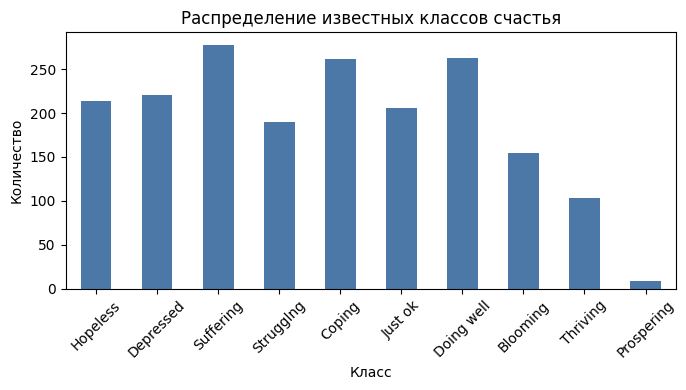

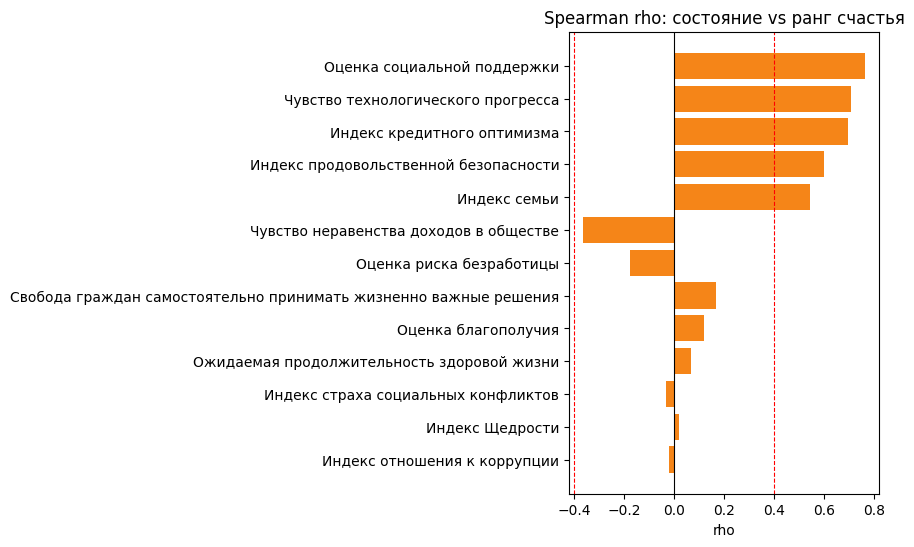

In [54]:
fig, ax = plt.subplots(figsize=(7, 4))
known[TARGET].value_counts().reindex(CLASS_ORDER).plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Распределение известных классов счастья")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 6))
plot_data = spearman_table.sort_values("abs_Spearman")
ax.barh(plot_data["state"], plot_data["Spearman"], color="#F58518")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(-RHO_MIN, color="red", linewidth=0.8, linestyle="--")
ax.axvline(RHO_MIN, color="red", linewidth=0.8, linestyle="--")
ax.set_title("Spearman rho: состояние vs ранг счастья")
ax.set_xlabel("rho")
plt.tight_layout()
plt.show()

In [ ]:
# Диагностика МНК: сначала линейная модель, затем банк линеаризующих преобразований.
train = report["train"]
X_linear = make_cause_X(train, cause_cols=SELECTED_CAUSES, use_sphere=True, use_community=False)
X_bank = make_linearized_X(train, SELECTED_CAUSES, spec=report["bank_spec"], use_sphere=True, use_community=False)
ols_rows = []
for state in TOP_STATES:
    y = train[state].astype(float)
    ols = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("ols", LinearRegression())]).fit(X_linear, y)
    ridge_bank = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("ridge", Ridge(alpha=REG_ALPHA))]).fit(X_bank, y)
    coefs = pd.Series(ols.named_steps["ols"].coef_, index=X_linear.columns)
    main_feature = coefs.abs().idxmax()
    ols_rows.append({
        "state": state,
        "linear_R2_train": ols.score(X_linear, y),
        "bank_R2_train": ridge_bank.score(X_bank, y),
        "delta_R2": ridge_bank.score(X_bank, y) - ols.score(X_linear, y),
        "main_linear_feature": main_feature,
        "std_coef": coefs[main_feature],
    })
ols_summary = pd.DataFrame(ols_rows).sort_values("bank_R2_train", ascending=False)
display(ols_summary.round(4))


In [ ]:
y_test = report["test"]["rank"]
y_pred = report["test_pred"]
print(f"Report split seed={SEED}")
print(f"microprecision: {report['microprecision']:.4f}")
print(f"accuracy:       {report['accuracy']:.4f}")
print(f"target microprecision >= 0.6000: {report['microprecision'] >= 0.6}")
print(f"mean OOF R2 восстановления состояний: {report['state_OOF_R2_mean']:.4f}")
print(classification_report(y_test, y_pred, target_names=CLASS_ORDER, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=range(len(CLASS_ORDER)), display_labels=CLASS_ORDER, values_format="d", ax=ax)
ax.set_title(f"Confusion matrix, micro={report['microprecision']:.3f}")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Дополнительные графики для отчёта

Эти графики нужны для визуального обоснования линеаризации и роли сообществ:

- распределения причин и признаков состояния;
- пары признаков с умеренной ранговой связью `0.3 <= |rho Spearman| <= 0.75`;
- scatter-графики с LOWESS-сглаживанием, чтобы увидеть форму нелинейности;
- раскраска наблюдений по `community_id` и сфере занятости;
- PCA-карта по признакам-причинам для визуализации групп сообществ.

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.decomposition import PCA

plot_df = known.copy()
plot_numeric_cols = CAUSE_COLS + STATE_COLS

# Удобные короткие подписи для графиков.
short_names = {
    "Среднегодовой доход, тыс. $": "Доход, тыс. $",
    "Объем потребленного алкоголя в год, л.": "Алкоголь, л",
    "Количество членов семьи": "Семья, чел.",
    "Количество лет образования": "Лет образования",
    "Доля от дохода семьи которая тратится на продовольствие, %": "Доля дохода на еду",
    "Коэффициент Джини сообщества": "Джини",
    "Издержки сообщества на окружающую среду, млн. $": "Экология, млн. $",
    "Охват беспроводной связи в сообществе, %": "Охват связи, %",
    "Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек": "Смертность, тыс. чел.",
    "Волатильность потребительских цен в сообществе": "Волатильность цен",
    "Оценка социальной поддержки": "Соц. поддержка",
    "Чувство технологического прогресса": "Тех. прогресс",
    "Индекс кредитного оптимизма": "Кредитный оптимизм",
    "Индекс продовольственной безопасности": "Прод. безопасность",
    "Индекс семьи": "Индекс семьи",
    "Чувство неравенства доходов в обществе": "Неравенство доходов",
}

def label(col):
    return short_names.get(col, col[:35])

In [ ]:
# 1. Распределения оставшихся признаков-причин и top-состояний.
dist_cols = SELECTED_CAUSES + TOP_STATES
n_cols = 4
n_rows = int(np.ceil(len(dist_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.2 * n_rows))
axes = axes.ravel()

for ax, col in zip(axes, dist_cols):
    x = plot_df[col].dropna()
    ax.hist(x, bins=28, color="#4C78A8", alpha=0.82, edgecolor="white")
    ax.set_title(label(col))
    ax.set_ylabel("n")

for ax in axes[len(dist_cols):]:
    ax.axis("off")

plt.suptitle("Распределения оставшихся причин и выбранных признаков состояния", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# 2. Пары причина -> состояние: ищем монотонную нелинейность, где Spearman заметно выше Pearson.
pair_rows = []
for cause in SELECTED_CAUSES:
    for state in TOP_STATES:
        pair = plot_df[[cause, state]].dropna()
        rho, p_value = stats.spearmanr(pair[cause], pair[state])
        pearson, pearson_p = stats.pearsonr(pair[cause], pair[state])
        pair_rows.append({
            "cause": cause,
            "state": state,
            "Spearman": rho,
            "abs_Spearman": abs(rho),
            "Pearson": pearson,
            "abs_Pearson": abs(pearson),
            "Spearman_minus_Pearson_abs": abs(rho) - abs(pearson),
            "p-value": p_value,
        })

moderate_pairs = (
    pd.DataFrame(pair_rows)
    .query(f"{RHO_MIN} <= abs_Spearman <= {RHO_MAX}")
    .sort_values(["Spearman_minus_Pearson_abs", "abs_Spearman"], ascending=False)
    .reset_index(drop=True)
)

display(moderate_pairs.round(4))


In [12]:
# 4. Те же пары, но для каждого сообщества отдельная картинка:
#    всё сообщество подсвечивается красным и рисуется поверх серых точек остальных сообществ.

out_dir = Path("community_plots")
out_dir.mkdir(exist_ok=True)

show_pairs = moderate_pairs.head(6)
community_ids = plot_df["community_id"].dropna().unique()

# Убрать комментарии по необходимости (занимает минуту)

# for i, community_id in enumerate(community_ids, start=1):
#     n_cols = 2
#     n_rows = int(np.ceil(len(show_pairs) / n_cols))
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.8 * n_rows))
#     axes = np.array(axes).ravel()

#     for ax, row in zip(axes, show_pairs.itertuples(index=False)):
#         x_col, y_col = row.cause, row.state
#         data = plot_df[[x_col, y_col, CAT_COL, "community_id"]].dropna().copy()

#         others = data[data["community_id"] != community_id]
#         ax.scatter(
#             others[x_col], others[y_col],
#             s=18, alpha=0.35, color="lightgray",
#             edgecolors="none", zorder=1
#         )

#         community_part = data[data["community_id"] == community_id]
#         ax.scatter(
#             community_part[x_col], community_part[y_col],
#             s=24, alpha=0.85, color="red",
#             edgecolors="black", linewidths=0.2, zorder=3,
#             label="выбранное сообщество"
#         )

#         smoothed = lowess(data[y_col], data[x_col], frac=0.35, return_sorted=True)
#         ax.plot(smoothed[:, 0], smoothed[:, 1], color="black", linewidth=2.0, zorder=2)

#         ax.set_title(f"{label(x_col)} -> {label(y_col)}")
#         ax.set_xlabel(label(x_col))
#         ax.set_ylabel(label(y_col))

#     for ax in axes[len(show_pairs):]:
#         ax.axis("off")

#     handles, labels_ = axes[0].get_legend_handles_labels()
#     if handles:
#         fig.legend(handles, labels_, loc="upper center", ncol=1, bbox_to_anchor=(0.5, 1.02))

#     safe_name = f"community_{i:03d}.png"
#     fig.savefig(out_dir / safe_name, dpi=200, bbox_inches="tight")
#     plt.close(fig)

# print(f"Сохранено изображений: {len(community_ids)} в папку: {out_dir}")

Сохранено изображений: 25 в папку: community_plots


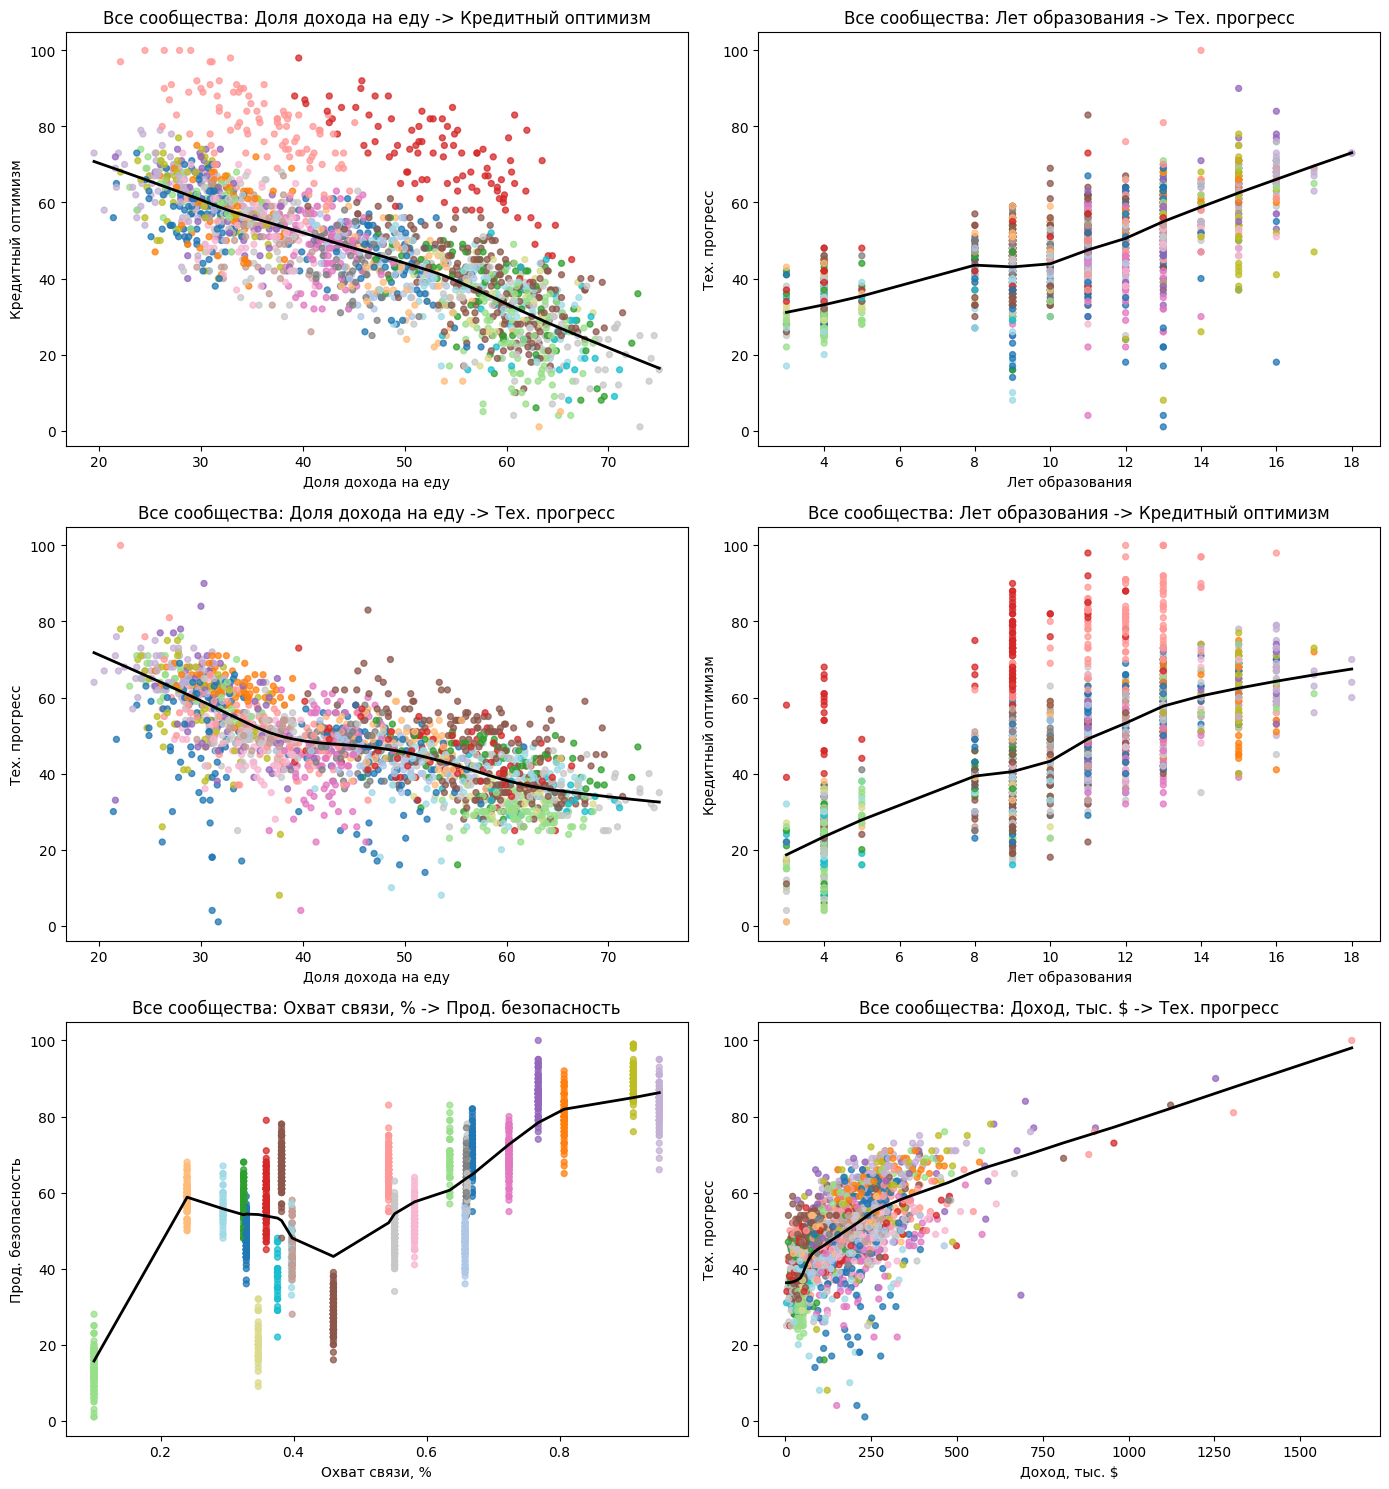

In [22]:
# Один общий график: все сообщества разными цветами (все пары на одном рисунке)
n_pairs = len(show_pairs)
n_cols = 2
n_rows = int(np.ceil(n_pairs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.array(axes).ravel()

for ax, row in zip(axes, show_pairs.itertuples(index=False)):
    x_col, y_col = row.cause, row.state
    data = plot_df[[x_col, y_col, "community_id"]].dropna().copy()
    community_codes = pd.factorize(data["community_id"])[0]

    ax.scatter(data[x_col], data[y_col], c=community_codes, cmap="tab20", s=18, alpha=0.75)
    smoothed = lowess(data[y_col], data[x_col], frac=0.35, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color="black", linewidth=2.0)

    ax.set_title(f"Все сообщества: {label(x_col)} -> {label(y_col)}")
    ax.set_xlabel(label(x_col))
    ax.set_ylabel(label(y_col))

for ax in axes[n_pairs:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 5. PCA-карта людей по оставшимся причинам: видны сообщества и положение unknown.
pca_features = SELECTED_CAUSES
X_known_pca = make_cause_X(known, cause_cols=pca_features, use_sphere=False, use_community=False)[pca_features]
X_unknown_pca = make_cause_X(unknown, cause_cols=pca_features, use_sphere=False, use_community=False)[pca_features]

pca_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42)),
])
known_2d = pca_pipe.fit_transform(X_known_pca)
unknown_2d = pca_pipe.transform(X_unknown_pca)
explained = pca_pipe.named_steps["pca"].explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
community_codes = pd.factorize(known["community_id"])[0]
axes[0].scatter(known_2d[:, 0], known_2d[:, 1], c=community_codes, cmap="tab20", s=18, alpha=0.65)
axes[0].set_title("Known: PCA по оставшимся причинам, цвет = community_id")
axes[0].set_xlabel(f"PC1 ({explained[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({explained[1]:.1%})")

rank_colors = known["rank"].values
sc = axes[1].scatter(known_2d[:, 0], known_2d[:, 1], c=rank_colors, cmap="viridis", s=18, alpha=0.55, label="known")
axes[1].scatter(unknown_2d[:, 0], unknown_2d[:, 1], c="red", marker="x", s=26, alpha=0.75, label="unknown")
axes[1].set_title("Known и unknown в пространстве оставшихся причин")
axes[1].set_xlabel(f"PC1 ({explained[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({explained[1]:.1%})")
axes[1].legend()
fig.colorbar(sc, ax=axes[1], label="rank счастья")

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
# 6. Heatmap корреляций: оставшиеся причины + top-состояния
heat_cols = SELECTED_CAUSES + TOP_STATES
corr = plot_df[heat_cols].corr(method="spearman")

corr_labeled = corr.copy()
corr_labeled.index = [label(c) for c in corr.index]
corr_labeled.columns = [label(c) for c in corr.columns]

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_labeled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linecolor="white",
    cbar_kws={"label": "Корреляция Спирмена"}
)

plt.title("Матрица корреляций между оставшимися причинами и состояниями")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Финальное обучение на всех known и прогноз 600 unknown.
_, final_top_states, final_cause_cols, final_vif_removed, final_vif_table, final_bank_spec = select_top_states(known)
X_known_reg = make_linearized_X(known, final_cause_cols, spec=final_bank_spec, use_sphere=True, use_community=False)
X_unknown_reg = make_linearized_X(unknown, final_cause_cols, spec=final_bank_spec, use_sphere=True, use_community=False, columns=X_known_reg.columns)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

final_reg = state_regressor(alpha=REG_ALPHA)
known_state_oof = cross_val_predict(final_reg, X_known_reg, known[final_top_states].astype(float), cv=cv.split(X_known_reg, known["rank"]))
final_reg.fit(X_known_reg, known[final_top_states].astype(float))
unknown_state_pred = final_reg.predict(X_unknown_reg)

X_known_clf = make_cause_X(known, cause_cols=final_cause_cols, use_sphere=True, use_community=False)
X_unknown_clf = make_cause_X(unknown, cause_cols=final_cause_cols, use_sphere=True, use_community=False, columns=X_known_clf.columns)
Z_known = make_classifier_X(known_state_oof, X_known_clf.set_index(known.index), final_top_states)
Z_unknown = make_classifier_X(unknown_state_pred, X_unknown_clf.set_index(unknown.index), final_top_states)

final_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(C=LOGREG_C, max_iter=8000, solver="lbfgs")),
])
final_clf.fit(Z_known, known["rank"])
unknown_rank = final_clf.predict(Z_unknown)

result = unknown[["ID"] + CAUSE_COLS + [CAT_COL]].copy()
for i, state in enumerate(final_top_states):
    result["pred_" + state] = unknown_state_pred[:, i]
result["predicted_rank"] = unknown_rank
result["predicted_happiness"] = [rank_to_class[i] for i in unknown_rank]
result.to_excel("main_unknown_predictions.xlsx", index=False)

print("Saved: main_unknown_predictions.xlsx")
print("Final selected causes:", len(final_cause_cols))
print("Final selected states:", len(final_top_states))
display(final_vif_removed.round(3) if len(final_vif_removed) else pd.DataFrame(columns=["removed_feature", "VIF_before_removal"]))
display(final_vif_table.round(3))
dist = result["predicted_happiness"].value_counts().reindex(CLASS_ORDER, fill_value=0)
display(dist.rename("unknown_prediction_count").to_frame())

fig, ax = plt.subplots(figsize=(7, 4))
dist.plot(kind="bar", ax=ax, color="#B279A2")
ax.set_title("Распределение прогнозов для unknown")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
